# State状态模式

在LangGraph框架中，无论构建的代理简单或者复杂，其本质都是通过节点(node)和边(edge)的有机组合来构建形成一个完整的图(graph)；
这种构建方式所形成的工作流逻辑十分清晰：每个节点在完成其任务后，都会通过边来指示下一个工作步骤，从而赋予整个应用系统更高的灵活性和可扩展性。
三个核心组件——状态（State）、节点（Node）和边（Edge），是LangGraph框架最基础的元素，也是构建复杂应用系统的基础。

关于state:
- State就像全局盒子，每个字段（节点node）上都贴一张“处理书名书”-reducer，用于描述该字段的处理规则。节点只负责扔数据进盒子（state）中，怎么处理数据就是有所在节点的reducer说了算；
- reducer是LangGraph内部的“状态合并规则配置项",更像一种概念工具而不是具体函数，是一种注解贴在了节点上；

业务逻辑写在node中；reducer只负责描述处理规则，不负责执行业务逻辑；而state则负责存储数据，表示全局的状态。


StateGraph是基于LangGraph的一种状态模式，用于构建状态机，是一个完整工具，自己定义state，自己定义reducer，自己定义状态机的流程。

In [ ]:
"""
class MyState(TypedDict):
    messages:Annotated[list,add_message] # 自己贴reducer
    num:int #额外字段
builder = StateGraph(MyState)
"""

MessageGraph类似于商店买的现成小盒子（预制好的），就是一个封装好的，可以直接用的库
只有一个格子(消息列表)，出厂就贴好“追加说明书”，是一种默认带了reducer的简化图；

In [ ]:
"""
builder = MessageGraph() # 直接用，state只能是消息列表，默认追加
MessageGraph = 预制state(仅消息列表) + 预制reducer(add_message追加消息)
# 核心代码：
def __init__(self):
    super().__init__(Annotated[list[AnyMessage]],add_message)
"""

# 使用字典类型定义状态State

1.将图的状态设计为一个字典类型

In [1]:
from langgraph.graph import StateGraph

# 构建图
builder  = StateGraph(dict)

2.定义两个节点

In [4]:
# 定义加法逻辑节点，以当前状态state为输入，将字典中的x值加1，返回新的状态字典
def addition(state):
    print(state)
    return {"x": state["x"] + 1}

# 定义减法逻辑节点，以当前状态state为输入，将字典中的x值减2，返回新的状态字典
def subtraction(state):
    print(state)
    return {"y": state["x"] - 2}

3.进行图结构的设计并编译

In [5]:
from langgraph.graph import START, END

# 向图中添加两个节点
builder.add_node("addition", addition)
builder.add_node("subtraction", subtraction)

# 构建节点之间的边
builder.add_edge(START, "addition")
builder.add_edge("addition", "subtraction")
builder.add_edge("subtraction", END)

# 编译图
graph = builder.compile()

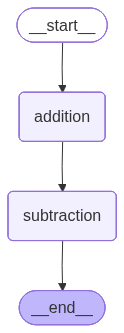

In [6]:
# 可视化图
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

测试

In [ ]:
# 定义一个初始化的状态
initial_state = {"x":10}
# graph.invoke(initial_state)
# 查看结果
print(graph.invoke(initial_state))



{'x': 10}
{'x': 11}
{'y': 9}


reducer其实就是节点中的合并规则，上面的例子中其实没有用到reducer，这样会直接覆盖，也就是每次输出的状态会直接覆盖上一个节点的输出。
如果需要定义节点之间传递状态，需要在节点中定义reducer函数。

# 加上reducer机制

1.TypedDicr定义状态模式，加上reducer机制

In [9]:
import operator
from typing import Annotated, TypedDict, List

class State(TypedDict):
    messages: Annotated[List[str], operator.add]
# messages是字典的一个键，表示某个字段，它的值是一个列表，列表中的每个元素都是一个字符串，表示一个消息。
# operator.add就相当于一个reducer机制，每次调用节点时，会将上一个节点的输出与当前节点的输入合并，得到一个新的状态。
# 这样就可以在节点之间传递状态，实现状态的累积和传递。
# Annotated允许在指定类型的同时附加额外的信息（例如，方法、操作符等）。

2.定义node

In [21]:
def addition(state):
    print(state)
    msg = state['messages'][-1]
    response = {'x': msg['x'] + 1}
    return {'messages': [response]}

def subtraction(state):
    print(state)
    msg = state['messages'][-1]
    response = {'y': msg['x'] - 2}
    return {'messages': [response]}

3.构建图

In [22]:
# 构建图
builder = StateGraph(State) 

# 向图中添加两个节点
builder.add_node("node1", addition)
builder.add_node("node2", subtraction)

# 构建节点之间的边
builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_edge("node2", END)

graph = builder.compile()

测试

In [23]:
input_state = {'messages': [{"x": 10}]}

graph.invoke(input_state)

{'messages': [{'x': 10}]}
{'messages': [{'x': 10}, {'x': 11}]}


{'messages': [{'x': 10}, {'x': 11}, {'y': 9}]}

Reducer机制的一个现实意义是：可以基于这种方式去构建历史对话记录。因为目前大多数大模型应用都是接受消息列表作为输入。 就像LangChain中的Chat Model，需要接收Message对象列表作为输入。这些消息有多种形式，例如HumanMessage （用户输入）或AIMessage （ 大模型响应）。

# 大模型接入LangGraph工作流进行动态消息处理与交互

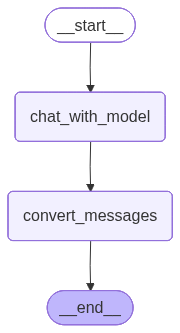

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import add_messages
from typing_extensions import TypedDict
from langgraph.graph import START, END
from typing import Optional
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 定义图的状态模式
class State(TypedDict):
    messages: Annotated[list, add_messages] 
    # 定义一个消息列表字段，使用add_messages作为reducer机制，实现消息的累积和传递

# 创建图的实例
builder = StateGraph(State)

# 定义图的节点，接收当前状态state作为输入，调用模型进行对话，并返回新的状态
def chat_with_model(state): # 聊天节点，ai回答自然语言
    print(state)
    print("-----------------")
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

def convert_messages(state): # 转换节点，将自然语言转换为json格式
    EXTRACTION_PROMPT = """
    您是一位数据提取专家，负责从文本中检索关键信息。请为所提供的文本提取相关信息，并以 JSON 格式输出。概述所提取的关键数据点。
    """
    messages = [
        SystemMessage(content=EXTRACTION_PROMPT),
        HumanMessage(content=state['messages'][-1].content)
    ]
    response = llm.invoke(messages)
    return {"messages": [response]}

# 添加节点
builder.add_node("chat_with_model", chat_with_model)
builder.add_node("convert_messages", convert_messages)

# 添加边
builder.add_edge(START, "chat_with_model")
builder.add_edge("chat_with_model", "convert_messages")
builder.add_edge("convert_messages", END)

# 编译图
graph = builder.compile()

# 可视化
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

测试

In [33]:
query="你好，请你介绍一下你自己"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)

print(result)

{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}, id='aaccafc8-2f0a-485d-bd72-81928c3fabc5')]}
-----------------
{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}, id='aaccafc8-2f0a-485d-bd72-81928c3fabc5'), AIMessage(content='你好！我叫Qwen，是由阿里云开发的大型语言模型。我的主要功能是生成与给定词语相关的高质量文本，帮助用户进行各种创作和交流活动。无论是撰写文章、创作故事、编写代码，还是提供信息查询，我都会尽力提供帮助。我基于大量的语言数据训练而成，旨在理解和生成自然语言，希望能够成为你的好帮手！如果你有任何问题或需要帮助，随时告诉我哦。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 34, 'total_tokens': 125, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': '', 'id': '019dfc99e88ff0c7d511fbcd6465276f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dfc99-e730-7850-b5af-4edbc042e7b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'outp

# 交互式聊天机器人

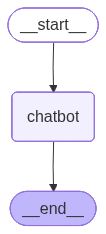

In [1]:
from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 定义图的状态模式
class State(TypedDict):
    messages: Annotated[list, add_messages] 
    # 定义一个消息列表字段，使用add_messages作为reducer机制，实现消息的累积和传递

# 创建图的实例
builder = StateGraph(State)

# 定义图的节点
def chatbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

# 添加节点
builder.add_node("chatbot", chatbot)

# 定义图的边
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 编译图
graph = builder.compile()

# 可视化图
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


通过一个程序完成聊天机器人的交互

In [4]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("模型回复:", value["messages"][-1].content)

while True:
    try:
        user_input = input("用户提问: ")
        if user_input.lower() in ["退出"]:
            print("下次再见！")
            break

        stream_graph_updates(user_input)
    except:
        break

模型回复: 哈喽，羊小明！很高兴认识你。你可以告诉我更多关于你自己的事情吗？比如你有什么兴趣爱好，或者最近在忙些什么呢？
模型回复: 您是使用我进行交流的用户。您可以通过提问或告诉我更多的信息，让我们之间的对话更加有趣和有意义。
模型回复: 您叫“啥”听起来像是个问题或者是在开玩笑。通常来说，您应该有一个具体的姓名。如果这是在进行某种特定的对话或者游戏，，请提供更多的背景信息，我将尽力提供帮助。如果您是想询问我的名字，那么我可以告诉您，我叫Qwen，是由阿里云开发的智能模型。
下次再见！
